In [2]:
import os, random
import numpy as np
import tensorflow as tf

SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print(f"Seeds fixed: {SEED}")

Seeds fixed: 42


In [3]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/MyDrive/alzheimer-ai/'

print("PROJECT_ROOT =", PROJECT_ROOT)

Mounted at /content/drive
PROJECT_ROOT = /content/drive/MyDrive/alzheimer-ai/


In [4]:
!pip install nibabel nilearn tf-keras-vis shap imbalanced-learn pytest -q
!pip install scikit-learn matplotlib seaborn pandas numpy pillow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 3.6 MB/s eta 0:00:00


In [5]:
!nvidia-smi

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU OK")
else:
    raise RuntimeError("No GPU found. Change Colab runtime to T4 GPU.")

Thu Jun 11 06:56:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   63C    P8             15W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [7]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, Model

os.makedirs(PROJECT_ROOT + 'weights', exist_ok=True)
os.makedirs(PROJECT_ROOT + 'logs', exist_ok=True)
os.makedirs(PROJECT_ROOT + 'reports/figures', exist_ok=True)
os.makedirs(PROJECT_ROOT + 'data/processed', exist_ok=True)

print("Imports ready.")

Imports ready.


In [8]:
IMAGE_ARRAY_DIR = PROJECT_ROOT + 'data/processed/image_arrays/'
TABULAR_DIR = PROJECT_ROOT + 'data/processed/tabular/'

required_files = [
    IMAGE_ARRAY_DIR + 'X_train.npy',
    IMAGE_ARRAY_DIR + 'X_val.npy',
    IMAGE_ARRAY_DIR + 'X_test.npy',
    TABULAR_DIR + 'y_train.npy',
    TABULAR_DIR + 'y_val.npy',
    TABULAR_DIR + 'y_test.npy',
    PROJECT_ROOT + 'data/processed/class_weight_dict.pkl'
]

for f in required_files:
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing required Day 2 file: {f}")

X_train = np.load(IMAGE_ARRAY_DIR + 'X_train.npy').astype(np.float32)
X_val = np.load(IMAGE_ARRAY_DIR + 'X_val.npy').astype(np.float32)
X_test = np.load(IMAGE_ARRAY_DIR + 'X_test.npy').astype(np.float32)

y_train = np.load(TABULAR_DIR + 'y_train.npy').astype(np.int64)
y_val = np.load(TABULAR_DIR + 'y_val.npy').astype(np.int64)
y_test = np.load(TABULAR_DIR + 'y_test.npy').astype(np.int64)

with open(PROJECT_ROOT + 'data/processed/class_weight_dict.pkl', 'rb') as f:
    class_weight_dict = pickle.load(f)

class_weight_dict = {int(k): float(v) for k, v in class_weight_dict.items()}

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

print("Class weights:", class_weight_dict)

print("Train class counts:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Val class counts:", dict(zip(*np.unique(y_val, return_counts=True))))
print("Test class counts:", dict(zip(*np.unique(y_test, return_counts=True))))

X_train: (262, 224, 224, 3)
X_val: (52, 224, 224, 3)
X_test: (59, 224, 224, 3)
y_train: (262,)
y_val: (52,)
y_test: (59,)
Class weights: {0: 0.6616161616161617, 1: 3.234567901234568, 2: 0.8478964401294499}
Train class counts: {np.int64(0): np.int64(132), np.int64(1): np.int64(27), np.int64(2): np.int64(103)}
Val class counts: {np.int64(0): np.int64(27), np.int64(1): np.int64(5), np.int64(2): np.int64(20)}
Test class counts: {np.int64(0): np.int64(31), np.int64(1): np.int64(5), np.int64(2): np.int64(23)}


In [9]:
assert X_train.shape[1:] == (224, 224, 3)
assert X_val.shape[1:] == (224, 224, 3)
assert X_test.shape[1:] == (224, 224, 3)

assert X_train.min() >= 0.0 and X_train.max() <= 1.0
assert X_val.min() >= 0.0 and X_val.max() <= 1.0
assert X_test.min() >= 0.0 and X_test.max() <= 1.0

assert len(X_train) == len(y_train)
assert len(X_val) == len(y_val)
assert len(X_test) == len(y_test)

print("Sanity checks passed.")

Sanity checks passed.


In [10]:
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

rotation_layer = tf.keras.layers.RandomRotation(0.10)
zoom_layer = tf.keras.layers.RandomZoom(0.05)


def augment_image(image):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.10)
    image = rotation_layer(image, training=True)
    image = zoom_layer(image, training=True)
    return tf.clip_by_value(image, 0.0, 1.0)


def make_image_dataset(X, y, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=42)

    if augment:
        ds = ds.map(
            lambda img, lbl: (augment_image(img), lbl),
            num_parallel_calls=AUTOTUNE
        )

    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


train_img_ds = make_image_dataset(X_train, y_train, augment=True, shuffle=True)
val_img_ds = make_image_dataset(X_val, y_val, augment=False, shuffle=False)
test_img_ds = make_image_dataset(X_test, y_test, augment=False, shuffle=False)

for batch_images, batch_labels in train_img_ds.take(1):
    print("Batch images:", batch_images.shape)
    print("Batch labels:", batch_labels.shape)
    print("Min:", tf.reduce_min(batch_images).numpy())
    print("Max:", tf.reduce_max(batch_images).numpy())

Batch images: (16, 224, 224, 3)
Batch labels: (16,)
Min: 0.0
Max: 0.9836165


In [11]:
def get_callbacks(model_name):
    """
    Identical callbacks for baseline and multimodal models.
    """
    return [
        tf.keras.callbacks.ModelCheckpoint(
            PROJECT_ROOT + f'weights/{model_name}_best.h5',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),

        tf.keras.callbacks.ModelCheckpoint(
            PROJECT_ROOT + f'weights/{model_name}_epoch_{{epoch:02d}}.h5',
            save_freq='epoch',
            verbose=0
        ),

        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        ),

        tf.keras.callbacks.TensorBoard(
            log_dir=PROJECT_ROOT + f'logs/{model_name}/',
            histogram_freq=1
        )
    ]

In [12]:
def build_baseline():
    """
    Baseline CNN-only model:
    MRI image → ResNet50 → GAP → Dense layers → Softmax(3)
    """
    base = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3),
        name='resnet50'
    )

    # Stage 1: freeze first 100 layers, train the remaining backbone part + classifier head
    for layer in base.layers[:100]:
        layer.trainable = False

    for layer in base.layers[100:]:
        layer.trainable = True

    x = layers.GlobalAveragePooling2D(name="gap")(base.output)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    out = layers.Dense(3, activation='softmax', name='output')(x)

    model = Model(inputs=base.input, outputs=out, name='baseline_resnet50')

    return model


model = build_baseline()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "baseline_resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,146,563 (92.11 MB)

 Trainable params: 20,011,267 (76.34 MB)

 Non-trainable params: 4,135,296 (15.77 MB)

In [13]:
h1 = model.fit(
    train_img_ds,
    validation_data=val_img_ds,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('baseline_stage1')
)

# Save Stage 1 backbone checkpoint
model.get_layer('resnet50').save_weights(
    PROJECT_ROOT + 'weights/backbone_resnet50_stage1.weights.h5'
)

print("Stage 1 completed and backbone checkpoint saved.")

Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.3025 - loss: 1.8257
Epoch 1: val_accuracy improved from None to 0.51923, saving model to /content/drive/MyDrive/alzheimer-ai/weights/baseline_stage1_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/alzheimer-ai/weights/baseline_stage1_best.h5


17/17 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.3130 - loss: 1.6250 - val_accuracy: 0.5192 - val_loss: 1.0778 - learning_rate: 1.0000e-04
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.3576 - loss: 1.5593
Epoch 2: val_accuracy did not improve from 0.51923


17/17 ━━━━━━━━━━━━━━━━━━━━ 15s 915ms/step - accuracy: 0.3702 - loss: 1.5666 - val_accuracy: 0.5192 - val_loss: 1.0808 - learning_rate: 1.0000e-04
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.3470 - loss: 1.3784
Epoch 3: val_accuracy did not improve from 0.51923


17/17 ━━━━━━━━━━━━━━━━━━━━ 15s 906ms/step - accuracy: 0.3817 - loss: 1.3560 - val_accuracy: 0.5192 - val_loss: 1.0968 - learning_rate: 1.0000e-04
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.3266 - loss: 1.5842
Epoch 4: val_accuracy did not improve from 0.51923


...

17/17 ━━━━━━━━━━━━━━━━━━━━ 15s 907ms/step - accuracy: 0.3359 - loss: 1.3696 - val_accuracy: 0.3077 - val_loss: 1.1544 - learning_rate: 1.0000e-04
Epoch 9/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.3492 - loss: 1.3394
Epoch 9: val_accuracy improved from 0.51923 to 0.53846, saving model to /content/drive/MyDrive/alzheimer-ai/weights/baseline_stage1_best.h5



Epoch 9: finished saving model to /content/drive/MyDrive/alzheimer-ai/weights/baseline_stage1_best.h5


17/17 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.3473 - loss: 1.3848 - val_accuracy: 0.5385 - val_loss: 1.0505 - learning_rate: 1.0000e-04
Epoch 10/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.4015 - loss: 1.1590
Epoch 10: val_accuracy did not improve from 0.53846



Epoch 10: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
17/17 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.3931 - loss: 1.2622 - val_accuracy: 0.5192 - val_loss: 1.0477 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 7.


ValueError: No such layer: resnet50. Existing layers are: ['input_layer', 'conv1_pad', 'conv1_conv', 'conv1_bn', 'conv1_relu', 'pool1_pad', 'pool1_pool', 'conv2_block1_1_conv', 'conv2_block1_1_bn', 'conv2_block1_1_relu', 'conv2_block1_2_conv', 'conv2_block1_2_bn', 'conv2_block1_2_relu', 'conv2_block1_0_conv', 'conv2_block1_3_conv', 'conv2_block1_0_bn', 'conv2_block1_3_bn', 'conv2_block1_add', 'conv2_block1_out', 'conv2_block2_1_conv', 'conv2_block2_1_bn', 'conv2_block2_1_relu', 'conv2_block2_2_conv', 'conv2_block2_2_bn', 'conv2_block2_2_relu', 'conv2_block2_3_conv', 'conv2_block2_3_bn', 'conv2_block2_add', 'conv2_block2_out', 'conv2_block3_1_conv', 'conv2_block3_1_bn', 'conv2_block3_1_relu', 'conv2_block3_2_conv', 'conv2_block3_2_bn', 'conv2_block3_2_relu', 'conv2_block3_3_conv', 'conv2_block3_3_bn', 'conv2_block3_add', 'conv2_block3_out', 'conv3_block1_1_conv', 'conv3_block1_1_bn', 'conv3_block1_1_relu', 'conv3_block1_2_conv', 'conv3_block1_2_bn', 'conv3_block1_2_relu', 'conv3_block1_

In [14]:
from tensorflow.keras.applications import ResNet50

def save_backbone_from_flat_model(model, output_path):
    """
    Extract ResNet50 backbone weights from a flattened Functional model
    and save them into a standalone ResNet50 backbone.
    """
    backbone = ResNet50(
        weights=None,
        include_top=False,
        input_shape=(224, 224, 3)
    )

    copied = 0
    skipped = []

    for layer in backbone.layers:
        try:
            source_layer = model.get_layer(layer.name)

            if len(source_layer.get_weights()) == len(layer.get_weights()):
                layer.set_weights(source_layer.get_weights())
                copied += 1
            else:
                skipped.append(layer.name)

        except Exception:
            skipped.append(layer.name)

    backbone.save_weights(output_path)

    print(f"Backbone weights saved to: {output_path}")
    print(f"Copied layers: {copied}")
    print(f"Skipped layers: {len(skipped)}")

    if skipped[:10]:
        print("First skipped layers:", skipped[:10])


save_backbone_from_flat_model(
    model,
    PROJECT_ROOT + 'weights/backbone_resnet50_stage1.weights.h5'
)

Backbone weights saved to: /content/drive/MyDrive/alzheimer-ai/weights/backbone_resnet50_stage1.weights.h5
Copied layers: 174
Skipped layers: 1
First skipped layers: ['input_layer_1']


In [15]:
# Stage 2 fine-tuning for flattened ResNet50 model

# Find where ResNet50 backbone ends
gap_index = [i for i, layer in enumerate(model.layers) if layer.name == 'gap'][0]

# Backbone layers are before the GAP layer
backbone_layers = model.layers[:gap_index]

print("Total model layers:", len(model.layers))
print("Backbone layers:", len(backbone_layers))
print("Classifier/head layers:", len(model.layers) - gap_index)

# Freeze all backbone layers except the last 50
for layer in backbone_layers[:-50]:
    layer.trainable = False

for layer in backbone_layers[-50:]:
    layer.trainable = True

# Keep classifier head trainable
for layer in model.layers[gap_index:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

h2 = model.fit(
    train_img_ds,
    validation_data=val_img_ds,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('baseline_stage2')
)

model.save(PROJECT_ROOT + 'weights/baseline_final.h5')

save_backbone_from_flat_model(
    model,
    PROJECT_ROOT + 'weights/backbone_resnet50.weights.h5'
)

print("Stage 2 completed.")
print("Saved baseline model:", PROJECT_ROOT + 'weights/baseline_final.h5')
print("Saved final backbone:", PROJECT_ROOT + 'weights/backbone_resnet50.weights.h5')

Total model layers: 182
Backbone layers: 175
Classifier/head layers: 7
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.4241 - loss: 1.2559
Epoch 1: val_accuracy improved from None to 0.53846, saving model to /content/drive/MyDrive/alzheimer-ai/weights/baseline_stage2_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/alzheimer-ai/weights/baseline_stage2_best.h5


17/17 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.4198 - loss: 1.2932 - val_accuracy: 0.5385 - val_loss: 1.0418 - learning_rate: 1.0000e-05
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.3671 - loss: 1.3231
Epoch 2: val_accuracy did not improve from 0.53846


17/17 ━━━━━━━━━━━━━━━━━━━━ 15s 907ms/step - accuracy: 0.3511 - loss: 1.2708 - val_accuracy: 0.5000 - val_loss: 1.0707 - learning_rate: 1.0000e-05
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.3883 - loss: 1.3399
Epoch 3: val_accuracy did not improve from 0.53846


17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 882ms/step - accuracy: 0.3817 - loss: 1.2550 - val_accuracy: 0.4615 - val_loss: 1.0834 - learning_rate: 1.0000e-05
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.4057 - loss: 1.3480
Epoch 4: val_accuracy did not improve from 0.53846



Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 844ms/step - accuracy: 0.3817 - loss: 1.2858 - val_accuracy: 0.4423 - val_loss: 1.0970 - learning_rate: 1.0000e-05
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.4176 - loss: 1.2436
Epoch 5: val_accuracy did not improve from 0.53846


17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 866ms/step - accuracy: 0.4160 - loss: 1.2100 - val_accuracy: 0.4231 - val_loss: 1.1079 - learning_rate: 5.0000e-06
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.4705 - loss: 1.3145
Epoch 6: val_accuracy did not improve from 0.53846


17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 881ms/step - accuracy: 0.4275 - loss: 1.3452 - val_accuracy: 0.4808 - val_loss: 1.0935 - learning_rate: 5.0000e-06
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


Backbone weights saved to: /content/drive/MyDrive/alzheimer-ai/weights/backbone_resnet50.weights.h5
Copied layers: 174
Skipped layers: 1
First skipped layers: ['input_layer_2']
Stage 2 completed.
Saved baseline model: /content/drive/MyDrive/alzheimer-ai/weights/baseline_final.h5
Saved final backbone: /content/drive/MyDrive/alzheimer-ai/weights/backbone_resnet50.weights.h5


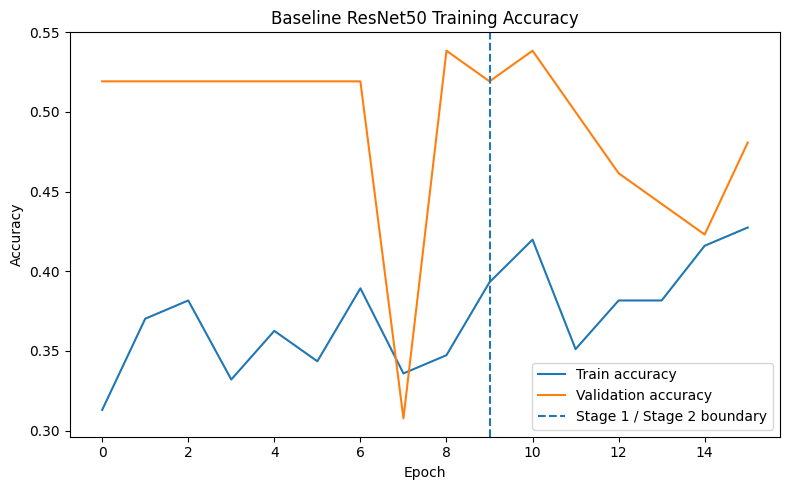

Saved: /content/drive/MyDrive/alzheimer-ai/reports/figures/baseline_training_accuracy.png


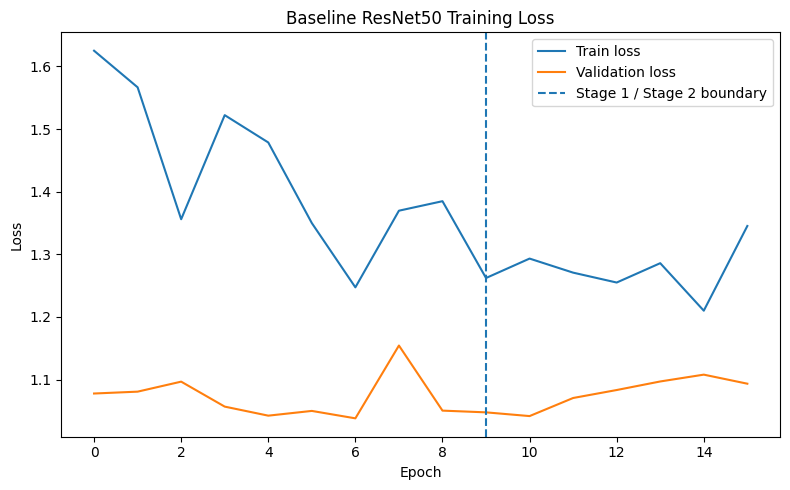

Saved: /content/drive/MyDrive/alzheimer-ai/reports/figures/baseline_training_loss.png


In [16]:
def merge_histories(h1, h2):
    merged = {}

    keys = set(list(h1.history.keys()) + list(h2.history.keys()))

    for key in keys:
        merged[key] = h1.history.get(key, []) + h2.history.get(key, [])

    return merged


history = merge_histories(h1, h2)

# Accuracy curve
plt.figure(figsize=(8, 5))
plt.plot(history['accuracy'], label='Train accuracy')
plt.plot(history['val_accuracy'], label='Validation accuracy')
plt.axvline(x=len(h1.history['accuracy']) - 1, linestyle='--', label='Stage 1 / Stage 2 boundary')
plt.title('Baseline ResNet50 Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()

acc_fig_path = PROJECT_ROOT + 'reports/figures/baseline_training_accuracy.png'
plt.savefig(acc_fig_path, dpi=150)
plt.show()

print("Saved:", acc_fig_path)

# Loss curve
plt.figure(figsize=(8, 5))
plt.plot(history['loss'], label='Train loss')
plt.plot(history['val_loss'], label='Validation loss')
plt.axvline(x=len(h1.history['loss']) - 1, linestyle='--', label='Stage 1 / Stage 2 boundary')
plt.title('Baseline ResNet50 Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()

loss_fig_path = PROJECT_ROOT + 'reports/figures/baseline_training_loss.png'
plt.savefig(loss_fig_path, dpi=150)
plt.show()

print("Saved:", loss_fig_path)

In [17]:
CLASSES = ['CN', 'MCI', 'MA']

y_proba = model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
y_pred = np.argmax(y_proba, axis=1)

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Recall macro': recall_score(y_test, y_pred, average='macro', zero_division=0),
    'F1 macro': f1_score(y_test, y_pred, average='macro', zero_division=0),
    'AUC-ROC': roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro'),
    'Recall MCI': recall_score(y_test == 1, y_pred == 1, zero_division=0),
    'Specificity': recall_score(y_test == 0, y_pred == 0, zero_division=0),
}

targets = {
    'Accuracy': 0.85,
    'Recall macro': 0.88,
    'F1 macro': 0.85,
    'AUC-ROC': 0.90,
    'Recall MCI': 0.85,
    'Specificity': 0.82,
}

print(f"\n{'Metric':<20}{'Value':>10}{'Target':>10}{'OK':>8}")
print("=" * 50)

for k, v in metrics.items():
    ok = "YES" if v >= targets[k] else "NO"
    print(f"{k:<20}{v:>10.4f}{targets[k]:>10.2f}{ok:>8}")

metrics_df = pd.DataFrame([
    {
        'metric': k,
        'value': v,
        'target': targets[k],
        'passed': v >= targets[k]
    }
    for k, v in metrics.items()
])

metrics_path = PROJECT_ROOT + 'data/processed/baseline_metrics.csv'
metrics_df.to_csv(metrics_path, index=False)

print("Saved:", metrics_path)

if metrics['Recall MCI'] < 0.85:
    print("\nWARNING: MCI recall is below 85%. Document says to activate imbalance mitigation after Day 3 if this happens.")

4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step

Metric                   Value    Target      OK
Accuracy                0.5254      0.85      NO
Recall macro            0.3333      0.88      NO
F1 macro                0.2296      0.85      NO
AUC-ROC                 0.5141      0.90      NO
Recall MCI              0.0000      0.85      NO
Specificity             1.0000      0.82     YES
Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/baseline_metrics.csv



In [19]:
print("True class counts:")
print(dict(zip(*np.unique(y_test, return_counts=True))))

print("\nPredicted class counts:")
print(dict(zip(*np.unique(y_pred, return_counts=True))))

print("\nClass mapping:")
print("0 = CN")
print("1 = MCI")
print("2 = MA")

True class counts:
{np.int64(0): np.int64(31), np.int64(1): np.int64(5), np.int64(2): np.int64(23)}

Predicted class counts:
{np.int64(0): np.int64(59)}

Class mapping:
0 = CN
1 = MCI
2 = MA


In [20]:
from tensorflow.keras.applications.resnet50 import preprocess_input

BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

rotation_layer = tf.keras.layers.RandomRotation(0.10)
zoom_layer = tf.keras.layers.RandomZoom(0.05)


def augment_image(image):
    # image enters as [0,1]
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.10)
    image = rotation_layer(image, training=True)
    image = zoom_layer(image, training=True)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image


def prepare_resnet_input(image):
    # ResNet50 ImageNet weights expect preprocess_input on 0..255-like images
    image = image * 255.0
    image = preprocess_input(image)
    return image


def make_image_dataset(X, y, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=42)

    if augment:
        ds = ds.map(
            lambda img, lbl: (augment_image(img), lbl),
            num_parallel_calls=AUTOTUNE
        )

    ds = ds.map(
        lambda img, lbl: (prepare_resnet_input(img), lbl),
        num_parallel_calls=AUTOTUNE
    )

    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


train_img_ds = make_image_dataset(X_train, y_train, augment=True, shuffle=True)
val_img_ds = make_image_dataset(X_val, y_val, augment=False, shuffle=False)
test_img_ds = make_image_dataset(X_test, y_test, augment=False, shuffle=False)

for batch_images, batch_labels in train_img_ds.take(1):
    print("Batch images:", batch_images.shape)
    print("Batch labels:", batch_labels.shape)
    print("Min:", tf.reduce_min(batch_images).numpy())
    print("Max:", tf.reduce_max(batch_images).numpy())

Batch images: (16, 224, 224, 3)
Batch labels: (16,)
Min: -123.68
Max: 151.061


In [22]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, Model, Input

def build_baseline_fixed(stage=1):
    """
    Baseline CNN-only ResNet50 model.
    This version keeps ResNet50 as a named nested layer: 'resnet50'.
    """
    img_input = Input(shape=(224, 224, 3), name="mri_input")

    base = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3),
        name='resnet50'
    )

    if stage == 1:
        n_freeze = 100
    else:
        n_freeze = len(base.layers) - 50

    for layer in base.layers[:n_freeze]:
        layer.trainable = False

    for layer in base.layers[n_freeze:]:
        layer.trainable = True

    x = base(img_input)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    out = layers.Dense(3, activation='softmax', name='output')(x)

    return Model(inputs=img_input, outputs=out, name='baseline_resnet50_fixed')


# IMPORTANT: this replaces the old flattened model
model = build_baseline_fixed(stage=1)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Top-level model layers:")
print([layer.name for layer in model.layers])

print("\nChecking ResNet50 layer:")
print(model.get_layer('resnet50').name)

model.summary()

Top-level model layers:
['mri_input', 'resnet50', 'gap', 'dense_2', 'batch_normalization_1', 'dropout_2', 'dense_3', 'dropout_3', 'output']

Checking ResNet50 layer:
resnet50


Model: "baseline_resnet50_fixed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mri_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,146,563 (92.11 MB)

 Trainable params: 20,011,267 (76.34 MB)

 Non-trainable params: 4,135,296 (15.77 MB)

In [23]:
h1 = model.fit(
    train_img_ds,
    validation_data=val_img_ds,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('baseline_fixed_stage1')
)

model.get_layer('resnet50').save_weights(
    PROJECT_ROOT + 'weights/backbone_resnet50_stage1_fixed.weights.h5'
)

print("Fixed Stage 1 completed.")

Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.2914 - loss: 1.9734
Epoch 1: val_accuracy improved from None to 0.34615, saving model to /content/drive/MyDrive/alzheimer-ai/weights/baseline_fixed_stage1_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/alzheimer-ai/weights/baseline_fixed_stage1_best.h5


17/17 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.2748 - loss: 1.8926 - val_accuracy: 0.3462 - val_loss: 1.2558 - learning_rate: 1.0000e-04
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.4170 - loss: 1.4292
Epoch 2: val_accuracy did not improve from 0.34615


17/17 ━━━━━━━━━━━━━━━━━━━━ 15s 934ms/step - accuracy: 0.3969 - loss: 1.4371 - val_accuracy: 0.2692 - val_loss: 1.2875 - learning_rate: 1.0000e-04
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.3011 - loss: 1.5008
Epoch 3: val_accuracy improved from 0.34615 to 0.36538, saving model to /content/drive/MyDrive/alzheimer-ai/weights/baseline_fixed_stage1_best.h5



Epoch 3: finished saving model to /content/drive/MyDrive/alzheimer-ai/weights/baseline_fixed_stage1_best.h5


...

17/17 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.4733 - loss: 1.1678 - val_accuracy: 0.4808 - val_loss: 1.0888 - learning_rate: 1.0000e-04
Epoch 7/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.5280 - loss: 1.0487
Epoch 7: val_accuracy improved from 0.50000 to 0.53846, saving model to /content/drive/MyDrive/alzheimer-ai/weights/baseline_fixed_stage1_best.h5



Epoch 7: finished saving model to /content/drive/MyDrive/alzheimer-ai/weights/baseline_fixed_stage1_best.h5



Epoch 7: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
17/17 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.5229 - loss: 0.9619 - val_accuracy: 0.5385 - val_loss: 1.1298 - learning_rate: 1.0000e-04
Epoch 8/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.5072 - loss: 0.9837
Epoch 8: val_accuracy did not improve from 0.53846


17/17 ━━━━━━━━━━━━━━━━━━━━ 32s 922ms/step - accuracy: 0.4962 - loss: 1.0201 - val_accuracy: 0.4615 - val_loss: 1.2624 - learning_rate: 5.0000e-05
Epoch 9/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.4533 - loss: 1.1210
Epoch 9: val_accuracy did not improve from 0.53846


17/17 ━━━━━━━━━━━━━━━━━━━━ 16s 978ms/step - accuracy: 0.4809 - loss: 1.0804 - val_accuracy: 0.5000 - val_loss: 1.4334 - learning_rate: 5.0000e-05
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 4.
Fixed Stage 1 completed.


In [24]:
base = model.get_layer('resnet50')

for layer in base.layers[:-50]:
    layer.trainable = False

for layer in base.layers[-50:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

h2 = model.fit(
    train_img_ds,
    validation_data=val_img_ds,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('baseline_fixed_stage2')
)

model.save(PROJECT_ROOT + 'weights/baseline_final.h5')

model.get_layer('resnet50').save_weights(
    PROJECT_ROOT + 'weights/backbone_resnet50.weights.h5'
)

print("Fixed Stage 2 completed.")
print("Saved corrected baseline_final.h5")
print("Saved corrected backbone_resnet50.weights.h5")

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.3875 - loss: 1.1513
Epoch 1: val_accuracy improved from None to 0.46154, saving model to /content/drive/MyDrive/alzheimer-ai/weights/baseline_fixed_stage2_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/alzheimer-ai/weights/baseline_fixed_stage2_best.h5


17/17 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.4351 - loss: 1.1849 - val_accuracy: 0.4615 - val_loss: 1.0178 - learning_rate: 1.0000e-05
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - accuracy: 0.4394 - loss: 1.2648
Epoch 2: val_accuracy did not improve from 0.46154


17/17 ━━━━━━━━━━━━━━━━━━━━ 16s 948ms/step - accuracy: 0.4618 - loss: 1.2310 - val_accuracy: 0.4615 - val_loss: 1.0537 - learning_rate: 1.0000e-05
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.4578 - loss: 1.1034
Epoch 3: val_accuracy did not improve from 0.46154


17/17 ━━━━━━━━━━━━━━━━━━━━ 15s 918ms/step - accuracy: 0.4313 - loss: 1.1910 - val_accuracy: 0.4615 - val_loss: 1.0832 - learning_rate: 1.0000e-05
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.4555 - loss: 1.1300
Epoch 4: val_accuracy improved from 0.46154 to 0.50000, saving model to /content/drive/MyDrive/alzheimer-ai/weights/baseline_fixed_stage2_best.h5


...


Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
17/17 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.4542 - loss: 1.1961 - val_accuracy: 0.5000 - val_loss: 1.1053 - learning_rate: 1.0000e-05
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.5018 - loss: 1.1460
Epoch 5: val_accuracy did not improve from 0.50000


17/17 ━━━━━━━━━━━━━━━━━━━━ 16s 967ms/step - accuracy: 0.4962 - loss: 1.1160 - val_accuracy: 0.5000 - val_loss: 1.1305 - learning_rate: 5.0000e-06
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.4142 - loss: 1.2208
Epoch 6: val_accuracy improved from 0.50000 to 0.51923, saving model to /content/drive/MyDrive/alzheimer-ai/weights/baseline_fixed_stage2_best.h5



Epoch 6: finished saving model to /content/drive/MyDrive/alzheimer-ai/weights/baseline_fixed_stage2_best.h5


17/17 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.4695 - loss: 1.0497 - val_accuracy: 0.5192 - val_loss: 1.1484 - learning_rate: 5.0000e-06
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


Fixed Stage 2 completed.
Saved corrected baseline_final.h5
Saved corrected backbone_resnet50.weights.h5


In [25]:
y_proba = model.predict(test_img_ds, verbose=1)
y_pred = np.argmax(y_proba, axis=1)

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Recall macro': recall_score(y_test, y_pred, average='macro', zero_division=0),
    'F1 macro': f1_score(y_test, y_pred, average='macro', zero_division=0),
    'AUC-ROC': roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro'),
    'Recall MCI': recall_score(y_test == 1, y_pred == 1, zero_division=0),
    'Specificity': recall_score(y_test == 0, y_pred == 0, zero_division=0),
}

targets = {
    'Accuracy': 0.85,
    'Recall macro': 0.88,
    'F1 macro': 0.85,
    'AUC-ROC': 0.90,
    'Recall MCI': 0.85,
    'Specificity': 0.82,
}

print(f"\n{'Metric':<20}{'Value':>10}{'Target':>10}{'OK':>8}")
print("=" * 50)

for k, v in metrics.items():
    ok = "YES" if v >= targets[k] else "NO"
    print(f"{k:<20}{v:>10.4f}{targets[k]:>10.2f}{ok:>8}")

metrics_df = pd.DataFrame([
    {
        'metric': k,
        'value': v,
        'target': targets[k],
        'passed': v >= targets[k]
    }
    for k, v in metrics.items()
])

metrics_path = PROJECT_ROOT + 'data/processed/baseline_metrics.csv'
metrics_df.to_csv(metrics_path, index=False)

print("Saved:", metrics_path)

print("\nTrue class counts:")
print(dict(zip(*np.unique(y_test, return_counts=True))))

print("\nPredicted class counts:")
print(dict(zip(*np.unique(y_pred, return_counts=True))))

4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 797ms/step

Metric                   Value    Target      OK
Accuracy                0.5254      0.85      NO
Recall macro            0.3633      0.88      NO
F1 macro                0.3430      0.85      NO
AUC-ROC                 0.5351      0.90      NO
Recall MCI              0.0000      0.85      NO
Specificity             0.7419      0.82      NO
Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/baseline_metrics.csv

True class counts:
{np.int64(0): np.int64(31), np.int64(1): np.int64(5), np.int64(2): np.int64(23)}

Predicted class counts:
{np.int64(0): np.int64(41), np.int64(2): np.int64(18)}


In [26]:
proba_df = pd.DataFrame(y_proba, columns=['P_CN', 'P_MCI', 'P_MA'])
proba_df['y_true'] = y_test
proba_df['y_pred'] = y_pred

print("Mean predicted probabilities by true class:")
display(proba_df.groupby('y_true')[['P_CN', 'P_MCI', 'P_MA']].mean())

print("\nMax MCI probability:")
print(proba_df['P_MCI'].max())

print("\nTop 10 samples by MCI probability:")
display(proba_df.sort_values('P_MCI', ascending=False).head(10))

Mean predicted probabilities by true class:


,P_CN,P_MCI,P_MA
y_true,,,
0,0.608175,0.091907,0.299919
1,0.535273,0.049189,0.415538
2,0.537588,0.044914,0.417498



Max MCI probability:
0.2395467609167099

Top 10 samples by MCI probability:


,P_CN,P_MCI,P_MA,y_true,y_pred
54,0.667872,0.239547,0.092581,0,0
36,0.512021,0.231643,0.256335,2,0
44,0.633303,0.228339,0.138358,0,0
45,0.634052,0.217506,0.148442,0,0
47,0.548789,0.192347,0.258865,0,0
23,0.524030,0.181551,0.294419,0,0
32,0.342472,0.155138,0.502390,0,2
16,0.542444,0.119833,0.337723,2,0
53,0.807732,0.118920,0.073347,0,0
1,0.505868,0.117782,0.376350,0,0


In [27]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])

cm_df = pd.DataFrame(
    cm,
    index=['Actual CN', 'Actual MCI', 'Actual MA'],
    columns=['Pred CN', 'Pred MCI', 'Pred MA']
)

display(cm_df)

,Pred CN,Pred MCI,Pred MA
Actual CN,23,0,8
Actual MCI,3,0,2
Actual MA,15,0,8


In [28]:
best_path = PROJECT_ROOT + 'weights/baseline_fixed_stage2_best.h5'

best_model = tf.keras.models.load_model(best_path)

best_y_proba = best_model.predict(test_img_ds, verbose=1)
best_y_pred = np.argmax(best_y_proba, axis=1)

best_metrics = {
    'Accuracy': accuracy_score(y_test, best_y_pred),
    'Recall macro': recall_score(y_test, best_y_pred, average='macro', zero_division=0),
    'F1 macro': f1_score(y_test, best_y_pred, average='macro', zero_division=0),
    'AUC-ROC': roc_auc_score(y_test, best_y_proba, multi_class='ovr', average='macro'),
    'Recall MCI': recall_score(y_test == 1, best_y_pred == 1, zero_division=0),
    'Specificity': recall_score(y_test == 0, best_y_pred == 0, zero_division=0),
}

print(f"\n{'Metric':<20}{'Final':>10}{'Best CKPT':>12}{'Target':>10}")
print("=" * 55)

for k in metrics.keys():
    print(f"{k:<20}{metrics[k]:>10.4f}{best_metrics[k]:>12.4f}{targets[k]:>10.2f}")

print("\nBest checkpoint predicted class counts:")
print(dict(zip(*np.unique(best_y_pred, return_counts=True))))

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 626ms/step

Metric                   Final   Best CKPT    Target
Accuracy                0.5254      0.5424      0.85
Recall macro            0.3633      0.3927      0.88
F1 macro                0.3430      0.3742      0.85
AUC-ROC                 0.5351      0.5586      0.90
Recall MCI              0.0000      0.0000      0.85
Specificity             0.7419      0.6129      0.82

Best checkpoint predicted class counts:
{np.int64(0): np.int64(31), np.int64(2): np.int64(28)}


In [29]:
# Use best validation-accuracy checkpoint as the final Day 3 baseline
model = best_model
y_proba = best_y_proba
y_pred = best_y_pred
metrics = best_metrics

model.save(PROJECT_ROOT + 'weights/baseline_final.h5')
model.get_layer('resnet50').save_weights(
    PROJECT_ROOT + 'weights/backbone_resnet50.weights.h5'
)

metrics_df = pd.DataFrame([
    {
        'metric': k,
        'value': v,
        'target': targets[k],
        'passed': v >= targets[k]
    }
    for k, v in metrics.items()
])

metrics_path = PROJECT_ROOT + 'data/processed/baseline_metrics.csv'
metrics_df.to_csv(metrics_path, index=False)

print("Using best validation-accuracy checkpoint as final baseline.")
print("Saved:", metrics_path)

Using best validation-accuracy checkpoint as final baseline.
Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/baseline_metrics.csv


In [30]:
# Use best validation-accuracy checkpoint as final Day 3 baseline

model = best_model
y_proba = best_y_proba
y_pred = best_y_pred
metrics = best_metrics

model.save(PROJECT_ROOT + 'weights/baseline_final.h5')
model.get_layer('resnet50').save_weights(
    PROJECT_ROOT + 'weights/backbone_resnet50.weights.h5'
)

metrics_df = pd.DataFrame([
    {
        'metric': k,
        'value': v,
        'target': targets[k],
        'passed': v >= targets[k]
    }
    for k, v in metrics.items()
])

metrics_path = PROJECT_ROOT + 'data/processed/baseline_metrics.csv'
metrics_df.to_csv(metrics_path, index=False)

print("Using best validation-accuracy checkpoint as final baseline.")
print("Saved final baseline model and backbone weights.")
print("Saved:", metrics_path)

print("\nFinal Day 3 baseline metrics:")
display(metrics_df)

print("\nFinal predicted class counts:")
print(dict(zip(*np.unique(y_pred, return_counts=True))))

Using best validation-accuracy checkpoint as final baseline.
Saved final baseline model and backbone weights.
Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/baseline_metrics.csv

Final Day 3 baseline metrics:


,metric,value,target,passed
0,Accuracy,0.542373,0.85,False
1,Recall macro,0.392707,0.88,False
2,F1 macro,0.374236,0.85,False
3,AUC-ROC,0.558608,0.90,False
4,Recall MCI,0.000000,0.85,False
5,Specificity,0.612903,0.82,False



Final predicted class counts:
{np.int64(0): np.int64(31), np.int64(2): np.int64(28)}


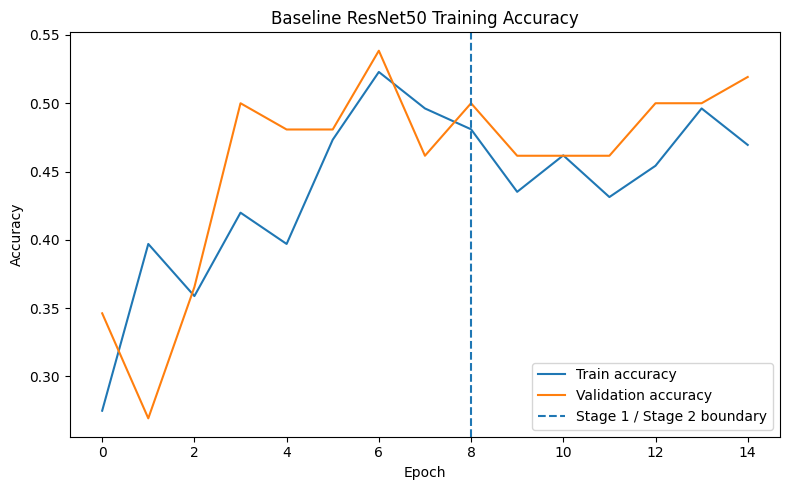

Saved: /content/drive/MyDrive/alzheimer-ai/reports/figures/baseline_training_accuracy.png


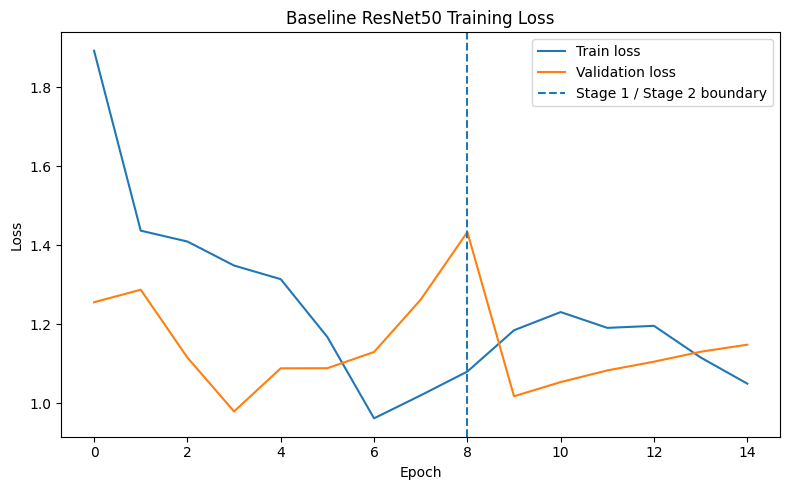

Saved: /content/drive/MyDrive/alzheimer-ai/reports/figures/baseline_training_loss.png


In [31]:
def merge_histories(h1, h2):
    merged = {}
    keys = set(list(h1.history.keys()) + list(h2.history.keys()))

    for key in keys:
        merged[key] = h1.history.get(key, []) + h2.history.get(key, [])

    return merged


history = merge_histories(h1, h2)

# Accuracy curve
plt.figure(figsize=(8, 5))
plt.plot(history['accuracy'], label='Train accuracy')
plt.plot(history['val_accuracy'], label='Validation accuracy')
plt.axvline(
    x=len(h1.history['accuracy']) - 1,
    linestyle='--',
    label='Stage 1 / Stage 2 boundary'
)
plt.title('Baseline ResNet50 Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()

acc_fig_path = PROJECT_ROOT + 'reports/figures/baseline_training_accuracy.png'
plt.savefig(acc_fig_path, dpi=150)
plt.show()

print("Saved:", acc_fig_path)

# Loss curve
plt.figure(figsize=(8, 5))
plt.plot(history['loss'], label='Train loss')
plt.plot(history['val_loss'], label='Validation loss')
plt.axvline(
    x=len(h1.history['loss']) - 1,
    linestyle='--',
    label='Stage 1 / Stage 2 boundary'
)
plt.title('Baseline ResNet50 Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()

loss_fig_path = PROJECT_ROOT + 'reports/figures/baseline_training_loss.png'
plt.savefig(loss_fig_path, dpi=150)
plt.show()

print("Saved:", loss_fig_path)

In [32]:
CLASSES = ['CN', 'MCI', 'MA']

report = classification_report(
    y_test,
    y_pred,
    target_names=CLASSES,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

display(report_df)

report_path = PROJECT_ROOT + 'data/processed/baseline_classification_report.csv'
report_df.to_csv(report_path)

print("Saved:", report_path)

,precision,recall,f1-score,support
CN,0.612903,0.612903,0.612903,31.000000
MCI,0.000000,0.000000,0.000000,5.000000
MA,0.464286,0.565217,0.509804,23.000000
accuracy,0.542373,0.542373,0.542373,0.542373
macro avg,0.359063,0.392707,0.374236,59.000000
weighted avg,0.503027,0.542373,0.520771,59.000000


Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/baseline_classification_report.csv


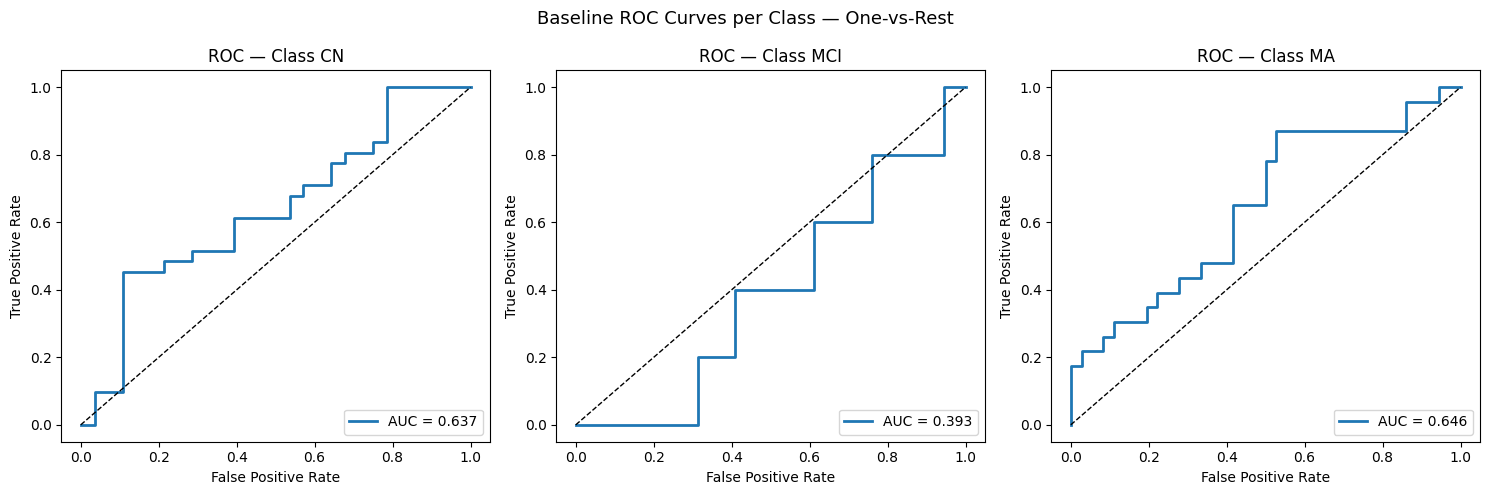

Saved: /content/drive/MyDrive/alzheimer-ai/reports/figures/baseline_roc_curves_per_class.png


In [33]:
y_bin = label_binarize(y_test, classes=[0, 1, 2])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, cls in enumerate(CLASSES):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)

    axes[i].plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
    axes[i].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].set_title(f'ROC — Class {cls}')
    axes[i].legend(loc='lower right')

plt.suptitle('Baseline ROC Curves per Class — One-vs-Rest', fontsize=13)
plt.tight_layout()

roc_fig_path = PROJECT_ROOT + 'reports/figures/baseline_roc_curves_per_class.png'
plt.savefig(roc_fig_path, dpi=150)
plt.show()

print("Saved:", roc_fig_path)

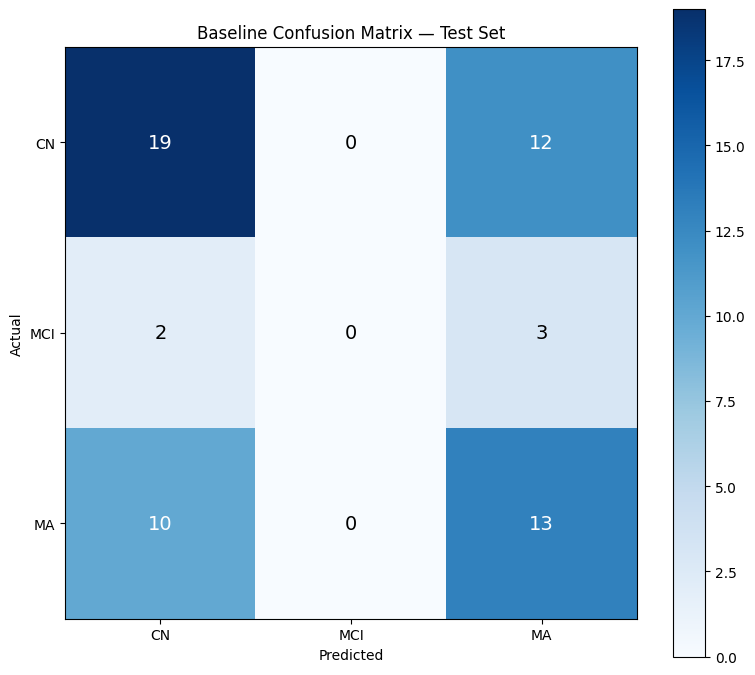

Saved: /content/drive/MyDrive/alzheimer-ai/reports/figures/baseline_confusion_matrix.png


,Pred CN,Pred MCI,Pred MA
Actual CN,19,0,12
Actual MCI,2,0,3
Actual MA,10,0,13


Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/baseline_confusion_matrix.csv

=== CONFUSION MATRIX ANALYSIS ===
MCI → CN: 2 cases — critical clinical error, missed MCI
MCI → MA: 3 cases — MCI over-classified as Alzheimer/MA
CN → MCI: 0 cases — false alarm
MCI → CN = 40.0% of MCI test cases
MCI recall = 0.0%
Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/baseline_confusion_narrative.txt


In [34]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(cm, cmap='Blues')

ax.set(
    xticks=range(3),
    yticks=range(3),
    xticklabels=CLASSES,
    yticklabels=CLASSES,
    xlabel='Predicted',
    ylabel='Actual',
    title='Baseline Confusion Matrix — Test Set'
)

for i in range(3):
    for j in range(3):
        ax.text(
            j,
            i,
            str(cm[i, j]),
            ha='center',
            va='center',
            color='white' if cm[i, j] > cm.max() / 2 else 'black',
            fontsize=14
        )

plt.colorbar(im)
plt.tight_layout()

cm_fig_path = PROJECT_ROOT + 'reports/figures/baseline_confusion_matrix.png'
plt.savefig(cm_fig_path, dpi=150)
plt.show()

print("Saved:", cm_fig_path)

cm_df = pd.DataFrame(
    cm,
    index=['Actual CN', 'Actual MCI', 'Actual MA'],
    columns=['Pred CN', 'Pred MCI', 'Pred MA']
)

display(cm_df)

cm_csv_path = PROJECT_ROOT + 'data/processed/baseline_confusion_matrix.csv'
cm_df.to_csv(cm_csv_path)

print("Saved:", cm_csv_path)

mci_cn = cm[1, 0]
mci_ma = cm[1, 2]
cn_mci = cm[0, 1]
mci_total = cm[1].sum()

print("\n=== CONFUSION MATRIX ANALYSIS ===")
print(f"MCI → CN: {mci_cn} cases — critical clinical error, missed MCI")
print(f"MCI → MA: {mci_ma} cases — MCI over-classified as Alzheimer/MA")
print(f"CN → MCI: {cn_mci} cases — false alarm")

if mci_total > 0:
    print(f"MCI → CN = {mci_cn / mci_total * 100:.1f}% of MCI test cases")
    print(f"MCI recall = {cm[1,1] / mci_total * 100:.1f}%")

narrative_path = PROJECT_ROOT + 'data/processed/baseline_confusion_narrative.txt'

with open(narrative_path, 'w') as f:
    f.write("Baseline CNN-only confusion matrix analysis\n")
    f.write("===========================================\n")
    f.write(f"MCI → CN: {mci_cn} cases — critical clinical error, missed MCI\n")
    f.write(f"MCI → MA: {mci_ma} cases — MCI over-classified as Alzheimer/MA\n")
    f.write(f"CN → MCI: {cn_mci} cases — false alarm\n")
    if mci_total > 0:
        f.write(f"MCI → CN = {mci_cn / mci_total * 100:.1f}% of MCI test cases\n")
        f.write(f"MCI recall = {cm[1,1] / mci_total * 100:.1f}%\n")
    f.write("\nConclusion: CNN-only baseline fails to detect MCI and motivates multimodal fusion with imbalance mitigation.\n")

print("Saved:", narrative_path)

In [35]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

X_all = np.concatenate([X_train, X_val, X_test], axis=0)
y_all = np.concatenate([y_train, y_val, y_test], axis=0)

feature_ds = make_image_dataset(
    X_all,
    y_all,
    augment=False,
    shuffle=False
)

feat_extractor = Model(
    inputs=model.input,
    outputs=model.get_layer('gap').output
)

X_feat = feat_extractor.predict(feature_ds, verbose=1)

print("Extracted CNN features:", X_feat.shape)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = []

for fold, (tr, vl) in enumerate(skf.split(X_feat, y_all)):
    clf = RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    clf.fit(X_feat[tr], y_all[tr])
    pred = clf.predict(X_feat[vl])

    score = f1_score(y_all[vl], pred, average='macro', zero_division=0)
    cv_scores.append(score)

    print(f"Fold {fold + 1}: F1 macro = {score:.4f}")

cv_mean = np.mean(cv_scores)
cv_std = np.std(cv_scores)

print(f"\nCV F1 macro: {cv_mean:.4f} ± {cv_std:.4f}")

cv_df = pd.DataFrame({
    'fold': list(range(1, 6)),
    'f1_macro': cv_scores
})

cv_df.loc[len(cv_df)] = ['mean', cv_mean]
cv_df.loc[len(cv_df)] = ['std', cv_std]

cv_path = PROJECT_ROOT + 'data/processed/baseline_cv_scores.csv'
cv_df.to_csv(cv_path, index=False)

print("Saved:", cv_path)

24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 170ms/step
Extracted CNN features: (373, 2048)
Fold 1: F1 macro = 0.3360
Fold 2: F1 macro = 0.3797
Fold 3: F1 macro = 0.3686
Fold 4: F1 macro = 0.3556
Fold 5: F1 macro = 0.3939

CV F1 macro: 0.3668 ± 0.0199
Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/baseline_cv_scores.csv


In [36]:
required_day3_outputs = [
    PROJECT_ROOT + 'weights/baseline_final.h5',
    PROJECT_ROOT + 'weights/backbone_resnet50.weights.h5',
    PROJECT_ROOT + 'reports/figures/baseline_training_accuracy.png',
    PROJECT_ROOT + 'reports/figures/baseline_training_loss.png',
    PROJECT_ROOT + 'reports/figures/baseline_roc_curves_per_class.png',
    PROJECT_ROOT + 'reports/figures/baseline_confusion_matrix.png',
    PROJECT_ROOT + 'data/processed/baseline_metrics.csv',
    PROJECT_ROOT + 'data/processed/baseline_classification_report.csv',
    PROJECT_ROOT + 'data/processed/baseline_confusion_matrix.csv',
    PROJECT_ROOT + 'data/processed/baseline_confusion_narrative.txt',
    PROJECT_ROOT + 'data/processed/baseline_cv_scores.csv',
]

for path in required_day3_outputs:
    print(os.path.exists(path), path)

True /content/drive/MyDrive/alzheimer-ai/weights/baseline_final.h5
True /content/drive/MyDrive/alzheimer-ai/weights/backbone_resnet50.weights.h5
True /content/drive/MyDrive/alzheimer-ai/reports/figures/baseline_training_accuracy.png
True /content/drive/MyDrive/alzheimer-ai/reports/figures/baseline_training_loss.png
True /content/drive/MyDrive/alzheimer-ai/reports/figures/baseline_roc_curves_per_class.png
True /content/drive/MyDrive/alzheimer-ai/reports/figures/baseline_confusion_matrix.png
True /content/drive/MyDrive/alzheimer-ai/data/processed/baseline_metrics.csv
True /content/drive/MyDrive/alzheimer-ai/data/processed/baseline_classification_report.csv
True /content/drive/MyDrive/alzheimer-ai/data/processed/baseline_confusion_matrix.csv
True /content/drive/MyDrive/alzheimer-ai/data/processed/baseline_confusion_narrative.txt
True /content/drive/MyDrive/alzheimer-ai/data/processed/baseline_cv_scores.csv


In [37]:
summary_path = PROJECT_ROOT + 'data/processed/day3_baseline_summary.txt'

with open(summary_path, 'w') as f:
    f.write("Day 3 — Baseline CNN-only ResNet50 Summary\n")
    f.write("==========================================\n\n")

    f.write("Final model used: best validation-accuracy checkpoint.\n")
    f.write("Architecture: ResNet50 CNN-only baseline.\n")
    f.write("Inputs: MRI slices only.\n")
    f.write("Classes: CN, MCI, MA.\n\n")

    f.write("Metrics:\n")
    for k, v in metrics.items():
        f.write(f"- {k}: {v:.4f} | target: {targets[k]:.2f} | passed: {v >= targets[k]}\n")

    f.write("\nClinical finding:\n")
    f.write("The CNN-only baseline fails to detect MCI. MCI recall remains 0%.\n")
    f.write("This triggers the document's imbalance-mitigation warning and justifies Day 4 multimodal fusion.\n")

print("Saved:", summary_path)

Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/day3_baseline_summary.txt


In [38]:
%cd /content/drive/MyDrive/alzheimer-ai/

!git status

!git add notebooks/03_baseline_cnn.ipynb

!git add reports/figures/baseline_training_accuracy.png
!git add reports/figures/baseline_training_loss.png
!git add reports/figures/baseline_roc_curves_per_class.png
!git add reports/figures/baseline_confusion_matrix.png

!git add -f data/processed/baseline_metrics.csv
!git add -f data/processed/baseline_classification_report.csv
!git add -f data/processed/baseline_confusion_matrix.csv
!git add -f data/processed/baseline_confusion_narrative.txt
!git add -f data/processed/baseline_cv_scores.csv
!git add -f data/processed/day3_baseline_summary.txt

!git commit -m "feat: complete Day 3 baseline CNN evaluation"

!git status

/content/drive/MyDrive/alzheimer-ai
Refresh index: 100% (25/25), done.
On branch main
Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/02_preprocessing.ipynb
	modified:   notebooks/02b_feature_engineering.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	notebooks/03_baseline_cnn.ipynb

no changes added to commit (use "git add" and/or "git commit -a")
The following paths are ignored by one of your .gitignore files:
reports/figures/baseline_training_accuracy.png
hint: Use -f if you really want to add them.
hint: Turn this message off by running
hint: "git config advice.addIgnoredFile false"
The following paths are ignored by one of your .gitignore files:
reports/figures/baseline_training_loss.png
hint: Use -f if you really want to add them.
hint: Turn this message off by running
hint: "git config advice.addIgnor